# 03 — Context-agnostic XLM-R baseline (RQ1) + the two §10 smoke tests

The baseline is `ContextAwareSarcasmModel` with all three channels OFF —
same class as the full model, so the RQ1 comparison can never drift.

Smoke tests required by guide §10 before the data gate is met:
1. **overfit-16** — drive training loss to ~0 on 16 rows (architecture sanity)
2. **tiny-settings 5-fold dry run** — prove the fold harness end-to-end

**Every number below is SMOKE** — tiny settings, pilot data, meaningless folds.

In [1]:
import matplotlib.pyplot as plt
import torch

from leische import data as D
from leische import evaluate as E
from leische import train as T
from leische.nbsupport import bootstrap

cfg, df, corpus, card, gate = bootstrap(config="configs/smoke.yaml", run_name="smoke-baseline")
SMOKE = cfg.tag()
folds = D.load_folds(cfg.folds_file(), card)
device = torch.device("cuda")

C:\Users\Gio\Documents\GitHub\leische\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 SMOKE MODE — every number in this notebook is a harness or
 architecture check on the pilot export, NOT a reportable result.
dataset identity: {'dataset_version': 'v1', 'prompt_version': 'sarc-v1', 'uyam_commit': '69d0affaca157edaf64e617d21e8ae752c9343fa'}
rows: 100  sarcastic: 8  corpus: not loaded

§10 data-readiness gate:
  [FAIL] dataset-v2 under sarc-v2 — dataset_version=v1, prompt_version=sarc-v1
  [FAIL] ≥400 sarcastic positives — 8 positives in export
  [FAIL] gold subset labeled + κ reported — n_gold_items=0, sarcastic κ=None
  [FAIL] every language×sarcastic cell ≥10 — thin cells: {'taglish|sarc=True': 5, 'english|sarc=True': 2, 'tagalog|sarc=True': 1}
  [PASS] fold file frozen — C:\Users\Gio\Documents\GitHub\leische\results\folds-v1.json
  => GATE FAILED: notebooks run in SMOKE mode only; no reported metrics.


## Smoke test 1 — overfit 16 rows to ~zero loss

Includes all 8 pilot positives + 8 negatives. A healthy architecture must be
able to memorize 16 rows; failure here means wiring bugs, not data problems.

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


C:\Users\Gio\Documents\GitHub\leische\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Gio\.cache\huggingface\hub\models--xlm-roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


SMOKE overfit-16: final mean loss 0.0364 over last 5 steps (27 steps) → PASS (target < 0.05)


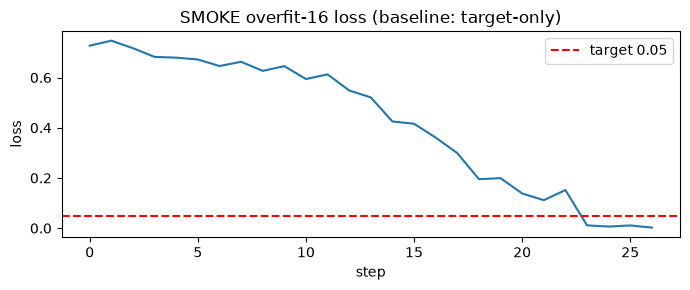

In [2]:
overfit = T.overfit_smoke(cfg, df, None, card, n=16, max_steps=150, target_loss=0.05)
plt.figure(figsize=(7, 3))
plt.plot(overfit["losses"])
plt.axhline(0.05, color="r", ls="--", label="target 0.05")
plt.title(f"{SMOKE}overfit-16 loss (baseline: target-only)")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()
assert overfit["passed"], "baseline failed to overfit 16 rows — architecture bug"

## Mean vs CLS pooling (guide §4.1 asks to verify both)

One tiny fold-0 run per pooling mode. At SMOKE scale this only proves both
paths execute — the real comparison happens post-gate.

In [3]:
from leische.config import LeischeConfig, find_repo_root

root = find_repo_root()
pooling_results = {}
for pooling in ("mean", "cls"):
    cfg_p = LeischeConfig.from_yaml(root / "configs/smoke.yaml", pooling=pooling,
                                    run_name=f"smoke-pooling-{pooling}")
    res = T.run_cv(cfg_p, df, None, card, folds[:1], verbose=False)
    m = res["fold_metrics"].iloc[0]
    pooling_results[pooling] = m
    print(f"{SMOKE}pooling={pooling}: fold-0 test F1={m['f1']:.4f} "
          f"(n_pos={int(m['n_pos'])}), best val F1={m['best_val_f1']:.4f}")
print(f"{SMOKE}both pooling paths run; thesis default stays pooling=mean.")

SMOKE pooling=mean: fold-0 test F1=0.0000 (n_pos=0), best val F1=0.0000


C:\Users\Gio\Documents\GitHub\leische\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


SMOKE pooling=cls: fold-0 test F1=0.0000 (n_pos=0), best val F1=0.0000
SMOKE both pooling paths run; thesis default stays pooling=mean.


## Smoke test 2 — tiny-settings 5-fold dry run (baseline)

Full harness: frozen folds → per-fold class weights → early stopping →
per-fold metrics → natural-only hygiene split → disaggregation.

In [4]:
res = T.run_cv(cfg, df, None, card, folds, verbose=True)
fm, preds = res["fold_metrics"], res["predictions"]

SMOKE fold 0 seed 13: test_f1=0.0000 (n_pos=0) val_f1=0.0000


SMOKE fold 1 seed 13: test_f1=0.0000 (n_pos=2) val_f1=0.0000


SMOKE fold 2 seed 13: test_f1=0.0000 (n_pos=1) val_f1=0.0000


SMOKE fold 3 seed 13: test_f1=0.0000 (n_pos=3) val_f1=0.0000


SMOKE fold 4 seed 13: test_f1=0.0000 (n_pos=2) val_f1=0.0000


In [5]:
print(f"{SMOKE}5-fold dry run, mean ± std across folds (1 seed, tiny settings):")
print(E.fold_summary(fm).to_string(index=False))
print(f"\n{SMOKE}§7.2 hygiene split (pilot has no keyword_oversampled rows, so "
      "natural-only == all — the code path is what's being exercised):")
print(E.natural_and_all(preds).to_string(index=False))

SMOKE 5-fold dry run, mean ± std across folds (1 seed, tiny settings):
 runs              f1       precision          recall        accuracy
    5 0.0000 ± 0.0000 0.0000 ± 0.0000 0.0000 ± 0.0000 0.9204 ± 0.0554

SMOKE §7.2 hygiene split (pilot has no keyword_oversampled rows, so natural-only == all — the code path is what's being exercised):
       slice  f1  precision  recall  accuracy   n  n_pos
natural_only 0.0        0.0     0.0      0.92 100      8
    all_rows 0.0        0.0     0.0      0.92 100      8


In [6]:
print(f"{SMOKE}F1 by language (several test folds hold 0 positives — that is the "
      "pilot's stratification failure, reported not hidden):")
print(E.slice_metrics(preds, "language").to_string(index=False))
print(f"\n{SMOKE}confusion matrix (rows=true, cols=pred):")
print(E.confusion(preds))
print(f"\n{SMOKE}calibration ECE (10 bins): {E.ece(preds['y_true'].to_numpy(), preds['prob'].to_numpy()):.4f}")

SMOKE F1 by language (several test folds hold 0 positives — that is the pilot's stratification failure, reported not hidden):
language  f1  precision  recall  accuracy  n  n_pos
 english 0.0        0.0     0.0  0.928571 28      2
 tagalog 0.0        0.0     0.0  0.941176 17      1
 taglish 0.0        0.0     0.0  0.909091 55      5

SMOKE confusion matrix (rows=true, cols=pred):
[[92  0]
 [ 8  0]]

SMOKE calibration ECE (10 bins): 0.3338


## Verdict

Both §10 smoke tests pass ⇒ the baseline harness is one config change away
from real training (`dataset_version: v2`, `smoke: false`) once the gate is met.

In [7]:
print(f"{SMOKE}smoke test 1 (overfit-16): PASS")
print(f"{SMOKE}smoke test 2 (5-fold dry run): PASS — {len(fm)} fold-runs completed, "
      f"artifacts in results/{cfg.run_name}/")

SMOKE smoke test 1 (overfit-16): PASS
SMOKE smoke test 2 (5-fold dry run): PASS — 5 fold-runs completed, artifacts in results/smoke-baseline/
